# RL coursework, part I (20 pts total)
---

**Name:** J.J. Moncus

**SN:** 25208363

---

**Due date:** *April 8th, 2026, 16:00*

---
Standard UCL policy (including grade deductions) automatically applies for any late submissions.


## How to submit

When you have completed the exercises and everything has finished running, click on 'File' in the menu-bar and then 'Download .ipynb'. This file must be submitted to Moodle named as **`<studentnumber>_RL_part1.ipynb`** before the deadline above, where `<studentnumber>` is your student number.

----
**Reminder of copyrights**

Copyrights protect this code/content and distribution or usages of it (or parts of it) without permission is prohibited. This includes uploading it and usage of it in training in any LLMs systems.

**Context**

In this assignment, we will take a first look at learning decisions from data.  For this, we will use the multi-armed bandit framework.

**Background reading**

* Sutton and Barto (2018), Chapters 1 to 6
* Lecture slides

**Overview of this assignment**

A) You will use Python to implement several bandit algorithms.

B) You will then run these algorithms on a multi-armed Bernoulli bandit problem, and answer question about their empirical performance.

C) You will then be asked to reason about the behaviour of different algorithms

## Setup

Run each of the cells below, until you reach the next section **Basic Agents**. You do not have to read or understand the code in the **Setup** section.  After running the cells, feel free to fold away the **Setup** section.

In [1]:
# Import Useful Libraries
import collections
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Import Seaborn

np.set_printoptions(precision=3, suppress=1)
sns.set_theme(style="white")

In [2]:
class BernoulliBandit(object):
  """A stationary multi-armed Bernoulli bandit."""

  def __init__(self, success_probabilities, success_reward=1., fail_reward=0.):
    """Constructor of a stationary Bernoulli bandit.

    Args:
      success_probabilities: A list or numpy array containing the probabilities,
          for each of the arms, of providing a success reward.
      success_reward: The reward on success (default: 1.)
      fail_reward: The reward on failure (default: 0.)
    """
    self._probs = success_probabilities
    self._number_of_arms = len(self._probs)
    self._s = success_reward
    self._f = fail_reward

    ps = np.array(success_probabilities)
    self._values = ps * success_reward + (1 - ps) * fail_reward

  def step(self, action):
    """The step function.

    Args:
      action: An integer or np.int32 that specifies which arm to pull.

    Returns:
      A reward sampled according to the success probability of the selected arm.

    Raises:
      ValueError: when the provided action is out of bounds.
    """
    if action < 0 or action >= self._number_of_arms:
      raise ValueError('Action {} is out of bounds for a '
                       '{}-armed bandit'.format(action, self._number_of_arms))

    success = bool(np.random.random() < self._probs[action])
    reward = success * self._s + (not success) * self._f
    return reward

  def regret(self, action):
    """Computes the regret for the given action."""
    return self._values.max() - self._values[action]

  def optimal_value(self):
    """Computes the regret for the given action."""
    return self._values.max()


In [3]:
class NonStationaryBandit(object):
  """A non-stationary multi-armed Bernoulli bandit."""

  def __init__(self, success_probabilities,
               success_reward=1., fail_reward=0., change_point=800,
               change_is_good=True):
    """Constructor of a non-stationary Bernoulli bandit.

    Args:
      success_probabilities: A list or numpy array containing the probabilities,
          for each of the arms, of providing a success reward.
      success_reward: The reward on success (default: 1.)
      fail_reward: The reward on failure (default: 0.)
      change_point: The number of steps before the rewards change.
      change_is_good: Whether the rewards go up (if True), or flip (if False).
    """
    self._probs = success_probabilities
    self._number_of_arms = len(self._probs)
    self._s = success_reward
    self._f = fail_reward
    self._change_point = change_point
    self._change_is_good = change_is_good
    self._number_of_steps_so_far = 0

    ps = np.array(success_probabilities)
    self._values = ps * success_reward + (1 - ps) * fail_reward

  def step(self, action):
    """The step function.

    Args:
      action: An integer or np.int32 that specifies which arm to pull.

    Returns:
      A reward sampled according to the success probability of the selected arm.

    Raises:
      ValueError: when the provided action is out of bounds.
    """
    if action < 0 or action >= self._number_of_arms:
      raise ValueError('Action {} is out of bounds for a '
                       '{}-armed bandit'.format(action, self._number_of_arms))

    self._number_of_steps_so_far += 1
    success = bool(np.random.random() < self._probs[action])
    reward = success * self._s + (not success) * self._f

    if self._number_of_steps_so_far == self._change_point:
      # After some number of steps, the rewards are inverted
      #
      #  ``The past was alterable. The past never had been altered. Oceania was
      #    at war with Eastasia. Oceania had always been at war with Eastasia.``
      #            - 1984, Orwell (1949).
      reward_dif = (self._s - self._f)
      if self._change_is_good:
        self._f = self._s + reward_dif
      else:
        self._s -= reward_dif
        self._f += reward_dif

      # Recompute expected values when the rewards change
      ps = np.array(self._probs)
      self._values = ps * self._s + (1 - ps) * self._f

    return reward

  def regret(self, action):
    """Computes the regret for the given action."""
    return self._values.max() - self._values[action]

  def optimal_value(self):
    """Computes the regret for the given action."""
    return self._values.max()

In [4]:
# Helper functions

def smooth(array, smoothing_horizon=100., initial_value=0.):
  """Smoothing function for plotting."""
  smoothed_array = []
  value = initial_value
  b = 1./smoothing_horizon
  m = 1.
  for x in array:
    m *= 1. - b
    lr = b/(1 - m)
    value += lr*(x - value)
    smoothed_array.append(value)
  return np.array(smoothed_array)

def plot(algs, plot_data, repetitions=30):
  """Plot results of a bandit experiment."""
  algs_per_row = 4
  n_algs = len(algs)
  n_rows = (n_algs - 2)//algs_per_row + 1
  fig = plt.figure(figsize=(10, 4*n_rows))
  fig.subplots_adjust(wspace=0.3, hspace=0.35)
  clrs = ['#000000', '#00bb88', '#0033ff', '#aa3399', '#ff6600']
  lss = ['--', '-', '-', '-', '-']
  for i, p in enumerate(plot_data):
    for c in range(n_rows):
      ax = fig.add_subplot(n_rows, len(plot_data), i + 1 + c*len(plot_data))
      ax.grid(0)

      current_algs = [algs[0]] + algs[c*algs_per_row + 1:(c + 1)*algs_per_row + 1]
      for alg, clr, ls in zip(current_algs, clrs, lss):
        data = p.data[alg.name]
        m = smooth(np.mean(data, axis=0))
        s = np.std(smooth(data.T).T, axis=0)/np.sqrt(repetitions)
        if p.log_plot:
          line = plt.semilogy(m, alpha=0.7, label=alg.name,
                              color=clr, ls=ls, lw=3)[0]
        else:
          line = plt.plot(m, alpha=0.7, label=alg.name,
                          color=clr, ls=ls, lw=3)[0]
          plt.fill_between(range(len(m)), m + s, m - s,
                           color=line.get_color(), alpha=0.2)
      if p.opt_values is not None:
        plt.plot(p.opt_values[current_algs[0].name][0], ':', alpha=0.5,
                 label='optimal')

      ax.set_facecolor('white')
      ax.tick_params(axis="both", which="both", bottom="off", top="off",
                     labelbottom="on", left="off", right="off", labelleft="on")
      ax.spines["top"].set_visible(False)
      ax.spines["bottom"].set(visible=True, color='black', lw=1)
      ax.spines["right"].set_visible(False)
      ax.spines["left"].set(visible=True, color='black', lw=1)
      ax.get_xaxis().tick_bottom()
      ax.get_yaxis().tick_left()

      data = np.array([smooth(np.mean(d, axis=0)) for d in p.data.values()])

      if p.log_plot:
        start, end = calculate_lims(data, p.log_plot)
        start = np.floor(np.log10(start))
        end = np.ceil(np.log10(end))
        ticks = [_*10**__
                 for _ in [1., 2., 3., 5.]
                 for __ in [-2., -1., 0.]]
        labels = [r'${:1.2f}$'.format(_*10** __)
                  for _ in [1, 2, 3, 5]
                  for __ in [-2, -1, 0]]
        plt.yticks(ticks, labels)
      plt.ylim(calculate_lims(data, p.log_plot))
      plt.locator_params(axis='x', nbins=4)

      plt.title(p.title)
      if i == len(plot_data) - 1:
        plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

def run_experiment(bandit_constructor, algs, repetitions, number_of_steps):
  """Run multiple repetitions of a bandit experiment."""
  reward_dict = {}
  regret_dict = {}
  optimal_value_dict = {}

  for alg in algs:
    reward_dict[alg.name] = np.zeros((repetitions, number_of_steps))
    regret_dict[alg.name] = np.zeros((repetitions, number_of_steps))
    optimal_value_dict[alg.name] = np.zeros((repetitions, number_of_steps))

    for _rep in range(repetitions):
      bandit = bandit_constructor()
      alg.reset()

      action = None
      reward = None
      for _step in range(number_of_steps):
        action = alg.step(action, reward)
        reward = bandit.step(action)
        regret = bandit.regret(action)
        optimal_value = bandit.optimal_value()

        reward_dict[alg.name][_rep, _step] = reward
        regret_dict[alg.name][_rep, _step] = regret
        optimal_value_dict[alg.name][_rep, _step] = optimal_value

  return reward_dict, regret_dict, optimal_value_dict


def train_agents(agents, number_of_arms, number_of_steps, repetitions=100,
                 success_reward=1., fail_reward=0.,
                 bandit_class=BernoulliBandit):

  success_probabilities = np.arange(0.3, 0.7 + 1e-6, 0.4/(number_of_arms - 1))

  bandit_constructor = partial(bandit_class,
                               success_probabilities=success_probabilities,
                               success_reward=success_reward,
                               fail_reward=fail_reward)
  rewards, regrets, opt_values = run_experiment(
      bandit_constructor, agents, repetitions, number_of_steps)

  smoothed_rewards = {}
  for agent, rs in rewards.items():
    smoothed_rewards[agent] = np.array(rs)

  PlotData = collections.namedtuple('PlotData',
                                    ['title', 'data', 'opt_values', 'log_plot'])
  total_regrets = dict([(k, np.cumsum(v, axis=1)) for k, v in regrets.items()])
  plot_data = [
      PlotData(title='Smoothed rewards', data=smoothed_rewards,
               opt_values=opt_values, log_plot=False),
      PlotData(title='Current Regret', data=regrets, opt_values=None,
               log_plot=True),
      PlotData(title='Total Regret', data=total_regrets, opt_values=None,
               log_plot=False),
  ]

  plot(agents, plot_data, repetitions)

def calculate_lims(data, log_plot=False):
  y_min = np.min(data)
  y_max = np.max(data)
  diff = y_max - y_min
  if log_plot:
    y_min = 0.9*y_min
    y_max = 1.1*y_max
  else:
    y_min = y_min - 0.05*diff
    y_max = y_max + 0.05*diff
  return y_min, y_max

def argmax(array):
  """Returns the maximal element, breaking ties randomly."""
  return np.random.choice(np.flatnonzero(array == array.max()))

# A) Agent implementations


All agents should be in pure Python/NumPy.

You cannot use any AutoDiff packages (Jax, TF, PyTorch, etc.)

Each agent, should implement the following methods:

**`step(self, previous_action, reward)`:**

Should update the statistics by updating the value for the previous_action towards the observed reward.

(Note: make sure this can handle the case that previous_action=None, in which case no statistics should be updated.)

(Hint: you can split this into two steps: 1. update values, 2. get new action.  Make sure you update the values before selecting a new action.)

**`reset(self)`:**

Resets statistics (should be equivalent to constructing a new agent from scratch).

Make sure that the initial values (after a reset) are all zero.

**`__init__(self, name, number_of_arms, *args)`:**

The `__init__` should take at least an argument `number_of_arms`, and (potentially) agent specific args.

## Example agent

The following code block contains an example random agent.

In [5]:
class Random(object):
  """A random agent.

  This agent returns an action between 0 and 'number_of_arms', uniformly at
  random. The 'previous_action' argument of 'step' is ignored.
  """

  def __init__(self, name, number_of_arms):
    """Initialise the agent.

    Sets the name to `random`, and stores the number of arms. (In multi-armed
    bandits `arm` is just another word for `action`.)
    """
    self._number_of_arms = number_of_arms
    self.name = name

  def step(self, unused_previous_action, unused_reward):
    """Returns a random action.

    The inputs are ignored, but this function still requires an action and a
    reward, to have the same interface as other agents who may use these inputs
    to learn.
    """
    return np.random.randint(self._number_of_arms)

  def reset(self):
    pass


## Q1 [2 pts]
Implement a UCB agent.

The `bonus_multiplier` is the parameter $c$ from the slides.

In [6]:
class UCB(object):
  def __init__(self, name, number_of_arms, bonus_multiplier):
    self._number_of_arms = number_of_arms
    self._bonus_multiplier = bonus_multiplier
    self.name = name
    self.reset()

  def step(self, previous_action, reward):
    
    # increment outcome for previous action
    if previous_action is not None:
        self.action_count[previous_action] += 1
        self.num_pulls += 1
        self.rewards[previous_action] += reward
    
    # get params for new action choice
    t = self.num_pulls
    N_a = self.action_count
    
    # calc value
    # Give unpulled arms infinite value to ensure they are picked first
    upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
    Q_a = self.rewards / (N_a + 1e-10) # mean reward per arm, up to now
    full_value = Q_a + (self._bonus_multiplier * upper_conf_bounds)
    
    # pull best arm
    action = np.argmax(full_value)
    return action

  def reset(self):

    self.action_count = np.zeros(self._number_of_arms)
    self.rewards = np.zeros(self._number_of_arms)
    self.num_pulls = 0
    return None

## Q2 [1 pt]
Implement an $\epsilon$-greedy agent.

This agent should be able to support time-changing $\epsilon$ schedules.

Thus, your agent should accept both constants and callables as constructor argument `epsilon`; callables are used to decay the $\epsilon$ parameter over time, for instance according to a polynomial schedule: $\epsilon_t = t^{-\eta}$ with $\eta \in [0, 1]$).


If multiple actions have the same value, ties should be broken randomly.

In [7]:
class EpsilonGreedy(object):
  """An epsilon-greedy agent.

  This agent returns an action between 0 and 'number_of_arms'; with probability
  `(1-epsilon)` it chooses the action with the highest estimated value, while
  with probability `epsilon` it samples an action uniformly at random.
  """

  def __init__(self, name, number_of_arms, epsilon=0.1):
    self.name = name
    self.number_of_arms = number_of_arms
    self.epsilon = epsilon
    self.reset()
    

  def get_current_epsilon(self):
        
        if callable(self.epsilon):
            # If it's a function, call it with the current timestep
            return self.epsilon(self.num_pulls + 1) # to ensure it's not zero
        # Otherwise, return it as a constant
        return self.epsilon

  def step(self, previous_action, reward):
    """Update the learnt statistics and return an action.

    A single call to step uses the provided reward to update the value of the
    taken action (which is also provided as an input), and returns an action.
    The action is either uniformly random (with probability epsilon), or greedy
    (with probability 1 - epsilon).

    If the input action is None (typically on the first call to step), then no
    statistics are updated, but an action is still returned.
    """
    ...
    
    # increment outcomes from previous action (if there was one)
    if previous_action is not None:
        self.action_count[previous_action] += 1
        self.num_pulls += 1
        self.rewards[previous_action] += reward

    # grab current epsilon
    current_eps = self.get_current_epsilon()

    # calc value
    # t = self.num_pulls
    N_a = self.action_count
    Q_a = self.rewards / (N_a + 1e-10) # mean reward per arm, up to now

    # --- Tie-Breaking Logic ---
    max_q = np.max(Q_a)
    tied_indices = np.where(Q_a == max_q)[0]
    
    if len(tied_indices) > 1:
        winner = np.random.choice(tied_indices)
        # Add a tiny amount to its Q-value to ensure argmax picks it
        Q_a[winner] += 1e-10
    # --------------------------
    
    # baseline eps prob of choosing an action
    baseline = current_eps / self.number_of_arms
    # assign eps probability to every action
    probs = np.ones(self.number_of_arms) * baseline

    # best action gets a lil more probability
    best_action = np.argmax(Q_a)
    probs[best_action] += 1 - current_eps
    
    arms = np.arange(self.number_of_arms)
    action = np.random.choice(arms, p = probs)
    return action

  def reset(self):

    self.action_count = np.zeros(self.number_of_arms)
    self.rewards = np.zeros(self.number_of_arms)
    self.num_pulls = 0
    return None

## Q3 [2 pts]
Implement a REINFORCE agent.

While `softmax` distributions are a common parametrization for policies over discrete action-spaces, they are not the only choice. In this exercise we ask you to implement REINFORCE with the `square-max` policy parameterization. With this parametrisation the probabilities depend on the action preferences $p(\cdot)$ according to the expression:

$$\pi(a) = \frac{p(a)^2}{\sum_b p(b)^2}\,.$$

Implement a REINFORCE policy-gradient method for updating the preferences under this policy distribution. The action preferences are stored separately, so that for each action $a$ the preference $p(a)$ is a single value that you directly update.

The agent should be able to use a baseline or not (as defined in the constructor). The `step_size` parameter $\alpha$ used to update the policy must also be configurable in the constructor.

The baseline should track the average reward so far, using the same `step_size` used to update the policy.

The `step_size` and whether or not a baseline is used are defined in the constructor by feeding additional arguments in place of `...` below.


In [8]:
class REINFORCE(object):
  def __init__(self, name, number_of_arms, step_size=0.1, baseline=False):
    self.name = name
    self.number_of_arms = number_of_arms
    self.step_size = step_size
    self.baseline = baseline
    self.reset()
  
  def get_current_step_size(self):
      
      if callable(self.step_size):
          # If it's a function, call it with the current timestep
          return self.step_size(self.num_pulls + 1) # to ensure it's not zero
      
      # Otherwise, return it as a constant
      return self.step_size

  def step(self, previous_action, reward):
    
    denom_prefs = np.sum(self.preferences**2)

    # if there was an action, update preferences
    if previous_action is not None:

      current_step_size = self.get_current_step_size()
      self.action_count[previous_action] += 1
      self.num_pulls += 1
      self.rewards[previous_action] += reward

      # the gradient updates for REINFORCE is step_size * reward * grad log policy
      # for this policy, preferences are single values (x_i)

      # update all values with the non-chosen-update first, 
      # then add the remaining update for the chosen action
      
      if self.baseline:
        target = reward - self.b
      else:
        target = reward

      non_chosen_update = (-2 * self.preferences)/ denom_prefs
      self.preferences += current_step_size * target * non_chosen_update
      self.preferences[previous_action] += current_step_size * target * (2 / self.preferences[previous_action])

      self.b += current_step_size * (reward - self.b)

    # choose next action
    denom_prefs = np.sum(self.preferences**2) # need to regrab denom after updates
    policy = self.preferences**2 / denom_prefs
    arms = np.arange(self.number_of_arms)
    action = np.random.choice(arms, p = policy)
    return action

  def reset(self):
    self.action_count = np.zeros(self.number_of_arms)
    self.rewards = np.zeros(self.number_of_arms)
    self.num_pulls = 0
    self.preferences = np.ones(self.number_of_arms)
    self.b = 0
    return None

# B) Experiments

**Run the cell below to train the agents and generate the plots for the first experiment.**

Trains the agents on a Bernoulli bandit problem with 5 arms,
with a reward on success of 1, and a reward on failure of 0.

## Experiment 1: Bernoulli bandit

In [9]:
%%capture experiment1

number_of_arms = 5
number_of_steps = 1000

agents = [
    Random(
        "random",
        number_of_arms),
    EpsilonGreedy(
        r"$\epsilon$-greedy with $\epsilon=0$",
        number_of_arms,
        epsilon=0.),
    EpsilonGreedy(
        r"$\epsilon$-greedy with $\epsilon=0.1$",
        number_of_arms,
        epsilon=0.1),
    EpsilonGreedy(
        r"$\epsilon$-greedy with $\epsilon_t=1/t$",
        number_of_arms,
        epsilon=lambda t: 1/t),
    EpsilonGreedy(
        r"$\epsilon$-greedy with $\epsilon_t=1/\sqrt{t}$",
        number_of_arms,
        epsilon=lambda t: 1./t**0.5),
    UCB("UCB",
        number_of_arms,
        bonus_multiplier=1/np.sqrt(2)),
    REINFORCE(
        r"REINFORCE, $\alpha=0.1$",
        number_of_arms,
        step_size=0.1,
        baseline=False),
    REINFORCE(
        r"REINFORCE with baseline, $\alpha=0.1$",
        number_of_arms,
        step_size=0.1,
        baseline=True),
]

train_agents(agents, number_of_arms, number_of_steps)

/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in log
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in sqrt
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)


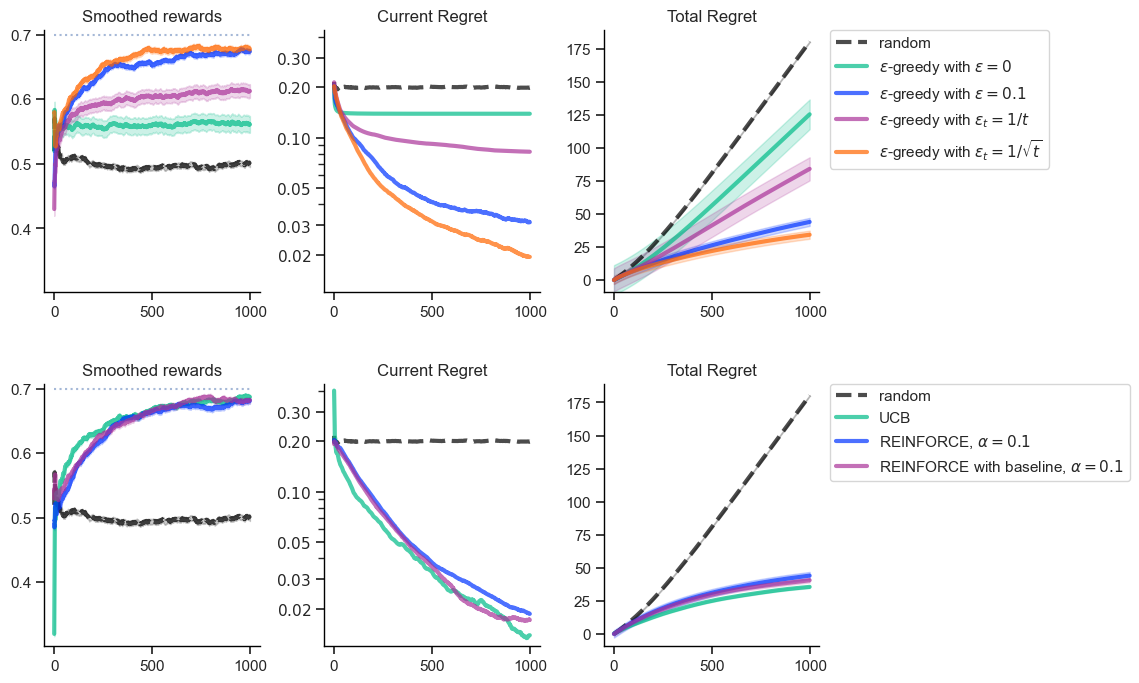

In [10]:
experiment1.show()

## Q4 [4 pts total]
(Answer inline in the markdown below each question, **within this text cell**.)

**[2 pts]**
For each algorithm in the plots above, explain whether or not we should be expected it to be good in general, in terms of total regret.

- A random policy does not exploit any knowledge, and so is expected to have high (linear) total regret as $t$ increases.
- $\epsilon$ greedy with constant $\epsilon$ achieves linear total regret in $t$, which is bad in the long run.
- $\epsilon$-greedy with a decaying $\epsilon$ achieves logarithmic total regret, and so should be much better in the long-run.
- For certain choices of $c$, UCB achieves logarithmic total regret. Choosing $c = \frac{1}{\sqrt 2}$ here corresponds to choosing maximal probability $p$ that the true action value exceeds an upper bound is falling as t increases, i.e. $p = 1/t$, i.e. this particular UCB should converge to low total regret in the limit.
- While the REINFORCE agent (both with an without a baseline) can converge to a good policy, it will acheive linear total regret in the limit, since it does not have a good mechanism for encouraging exploration forever. Adding a baseline reduces the variance of our updates, which leads to faster convergence to some good policy, but again, total regret could be linear.


**[2 pts]** Explain the relative ranking of the $\epsilon$-greedy algorithms in this experiment.

- $\epsilon$-greedy with $\epsilon = 0$ is just the greedy policy, which does not explore enough. It over-picks actions which by-chance resulted in high rewards early in training, which we know results in high total regret.
- $\epsilon$-greedy with a decaying $\epsilon = \frac{1}{\sqrt(t)}$ is the best for this problem - it explores just enough to find the good arms early, then exploits them at the right pace.
- Though we would expect decaying $\epsilon = \frac{1}{t}$ to beat constant $\epsilon = .1$ in the long run, $\frac{1}{t}$ seems too fast of a decay for this problem. $\epsilon = .1$ explores more early in training, which leads to better performance within the given time frame.

<!-- - We would expect $\epsilon$-greedy with a  to have logarithmic total regret in $t$ in the long run, but because $\epsilon$ decays so quickly, it stops exploring a little too early, and so appears out to lose out to constant $\epsilon = .1$ for t up to 1000 in this example, since it explores more. -->


## Experiment 2: reward = 0 on success, reward = -1 on failure.

**Run the cell below to train the agents and generate the plots for the second experiment.**
Reruns experiment 1 but on a different bernoulli bandit problem with 5 arms,
with a reward on success of 0, and a reward on failure of -1.

---



In [11]:
%%capture experiment2
number_of_arms = 5
number_of_steps = 1000

train_agents(agents, number_of_arms, number_of_steps,
             success_reward=0., fail_reward=-1.)

/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in log
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in sqrt
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)


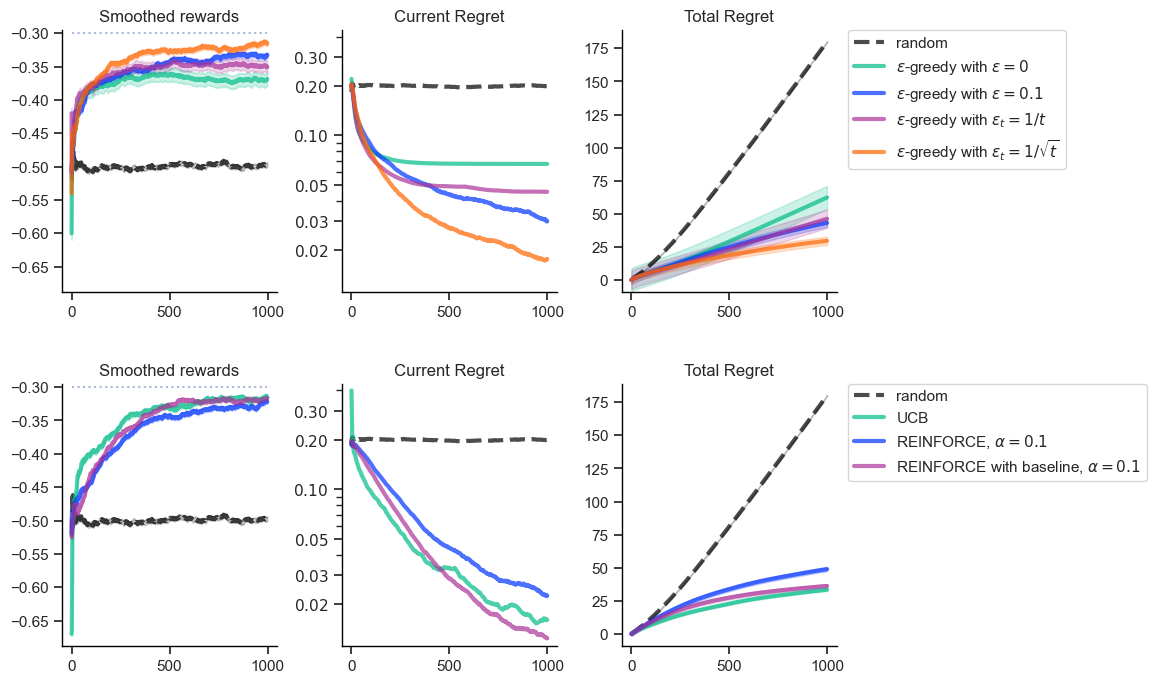

In [12]:
experiment2.show()

## Q5 [2 pts]
For each algorithm, note whether the performance changed significantly compared to the **experiment 1**, and explain why it did or did not.

(Use at most two sentences per algorithm).

- The greedy policy performs much better here - in this setup, this agent is guaranteed to try every arm at least once (and then stick with the one with highest reward). This is much more exploration than the previous setup, where the agent very well could be sticking with the first arm with positive reward withou trying others.
- $\epsilon = .1$ is roughly the same. 
- NOT SURE ABOUT THIS $\epsilon = \frac{1}{t}$ does better more quickly. The fast greed-ification of the policy is mediated by the fact that more arms have the same action value (0) for slightly longer early in training. 
- $\epsilon = \frac{1}{\sqrt t}$ is roughly the same. 
- UCB does the same. In the both setups, the agent explores a similar amount, until the upper-confidence bounds fall significantly.
- The gap between REINFORCE with and without a baseline is larger in this setup than before. With negative rewards, the baseline is a negative number, so the return $G_t - b$ is larger than in the prior setup, which means good arms here get bigger updates than good arms in the previous setup.

## Run the following cells

## Experiment 3: Non-stationary bandit
 * Reward on `failure` changes from 0 to +2.
 * Reward on `success` remains at +1.


In [13]:
%%capture experiment3

number_of_arms = 3
number_of_steps = 1984
agents = [
    Random(
        "random",
        number_of_arms),
    EpsilonGreedy(
        r"$\epsilon$-greedy with $\epsilon=0.1$",
        number_of_arms,
        epsilon=0.1),
    EpsilonGreedy(
        r"$\epsilon$-greedy with $\epsilon_t=1/\sqrt{t}$",
        number_of_arms,
        epsilon=lambda t: 1./t**0.5),
    UCB("UCB",
        number_of_arms,
        bonus_multiplier=1/np.sqrt(2)),
    REINFORCE(
        r"REINFORCE with baseline, $\alpha=0.1$",
        number_of_arms,
        step_size=0.1,
        baseline=True),

]

roving_bandit_class = partial(NonStationaryBandit, change_is_good=True)
train_agents(agents, number_of_arms, number_of_steps,
             bandit_class=roving_bandit_class)

## Experiment 4: Non-stationary bandit
 * Reward on `failure` changes from 0 to +1.
 * Reward on `success` changes from +1 to 0.


In [14]:
%%capture experiment4

number_of_arms = 3
number_of_steps = 1984


roving_bandit_class = partial(NonStationaryBandit, change_is_good=False)
train_agents(agents, number_of_arms, number_of_steps,
             bandit_class=roving_bandit_class)

/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in log
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in sqrt
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)


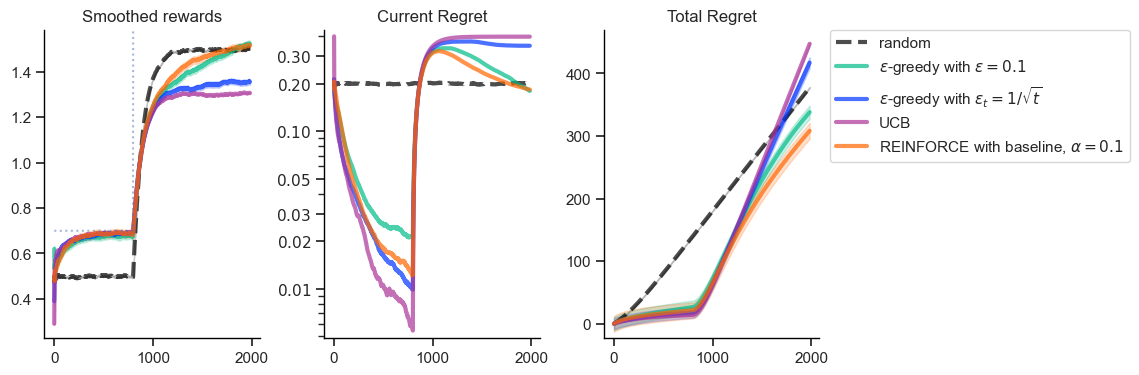

In [15]:
experiment3.show()

/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in log
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in sqrt
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: invalid value encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)
/var/folders/tv/n3k6_fsd1399026cv2pr0n1r0000gn/T/ipykernel_88557/3774086680.py:22: RuntimeWarning: divide by zero encountered in divide
  upper_conf_bounds = np.where(N_a > 0, np.sqrt( np.log(t) /  N_a ), np.inf)


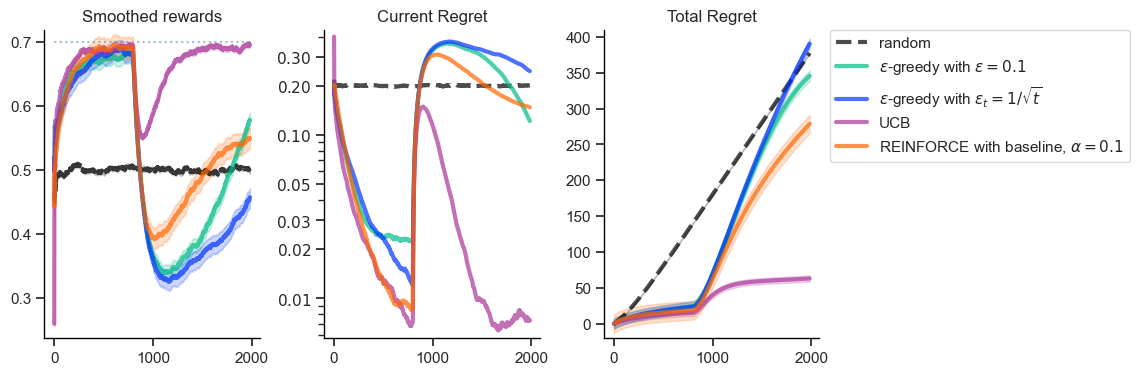

In [16]:
experiment4.show()

## Q6 [9 pts total]

Observe the reward and regret curves above.  After 800 steps, the rewards change. In **experiment 3** `success` continues to yield a reward of +1, but `failure` changes from a reward of 0 to a reward of +2.  In **experiment 4**, `success` is now worth 0 and `failure` is worth +1.

Below, we ask for explanations.  Answer each question briefly, using at most three sentences per question.

**[2 pts]** In **experiment 3** explain the ranking in current regret after the change in rewards for all algorithms.

> UCB and $\epsilon = \frac{1}{\sqrt t}$ do poorly because their exploration mechanism has been exhausted after $t = 800$, so they will rarely choose the actions which now have highest rewards, and the action-values for those arms take a long time to be updated. Constant $\epsilon$ is always exploring, and so lands on the new best arms after some time. REINFORCE is the fastest to respond well because it learns a policy directly, as opposed to through action values, by updating its preference values relative to the new rewards and can learn a good new policy with enough time-steps.

**[2 pts]** In **experiment 4** explain the ranking in current regret after the change in rewards for all algorithms.

> As before, $\epsilon = \frac{1}{\sqrt t}$ does not explore much after $t = 800$, so the action values for now-good arms take a long time to be updated. Constant $\epsilon explores more and updates action values for now-good arms more often. As before, REINFORCE updates its preference values relative to new rewards with enough time steps. UCB reacts very quickly because the action-values for the arms it previously thought were good fall quickly, leading it to explore new arms and inevitably find the new-good ones.

**[2 pts]** Explain how and why the current-regret curve for UCB in **experiment 3** differs from the curve in **experiment 4**.

> In experiment 3, the agent rarely updates the action values for "failure arms" because it keeps pulling arms that lead to success, so the agent never learns that failure is now worth more. In exp. 4, the "failure arms" get updated much more quickly because the action-values for "success arms" drop precipitously. This agent is encouraged to find out that failure is now good only because success became bad at the same time.

**[3 pts]** In general, if rewards can be non-stationary, and we don't know the exact nature of the non-stationarity, how could we modify UCB to perform better?   Be specific and concise.

> The agent needs some incentive to continue exploring arms which it thought were bad but might now be good. Instead of defining the upper-confidence bound with respect to the full history of arm-pulls, we could use only a sliding-window of $n$ steps, where $N(a)$ is the number arm pulls in that window, and the action_value $Q(a)$ is just the average reward within that time frame.
